# 3. Network Inference (v3)

Infers the gene regulatory network using two parallel approaches.
- **Section A (primary):** Cell-level ROLS. Loads single-cell data, builds PerturbSeq object, samples pseudoreplicates (`generate_mra_input`), fits local connectivity matrix (`run_jax_mra`), computes global response matrix G, infers edges by z-score on the cosine similarity matrix. Uses results obtained from UCD Sonic runs.
- **Section B (baseline):** Pseudobulk BMRA. Uses cross-perturbation matrices from Notebook 2 via the cSTAR formula. Used as diagnostic and comparison point.

**Note:** BTLA inference is skipped for Rest and Stim48hr (`SKIP_BTLA=True`).

---

### Nomenclature (cSTAR convention)

This notebook uses the variable names from our pipeline (`A_local`, `G_global`), which correspond to Oleksii's lowercase/uppercase convention as follows:

| This pipeline | Oleksii / HUVEC reference | Meaning |
|---|---|---|
| `A_local` / `A_rols` / `A_arr` | `r` (lowercase) | Local connectivity matrix. Output of MRA/ROLS. Diagonal set to −1 before inversion. |
| `G_global` / `G_rols` / `G_arr` | `R` (uppercase) | Global response matrix. Computed as `G = −pinv(A)`. Diagonal zeroed after inversion (no self-connections). |

The pseudobulk path computes `A_local = R_norm` (cross-perturbation matrix normalised by its diagonal, then diagonal set to −1), then `G = −pinv(A_local)`. This matches `03_bmra.ipynb` (HUVEC reference), cells 8–10 and 16.


### Configuration + Imports

In [1]:
import os
print(f'Working directory: {os.getcwd()}')

# Must match Notebooks 1 and 2
CONDITION = 'Rest' # 'Rest' | 'Stim8hr' | 'Stim48hr'
DONORS = ['D1', 'D2', 'D3', 'D4']
donors_tag = '_'.join(DONORS)
run_tag = f'{CONDITION}_{donors_tag}'

# Paths
DATA_DIR = '../Data'
IN_DIR = f'../Results/{CONDITION}' # Notebook 1+2 outputs
ROLS_OUT = os.path.join(IN_DIR, 'rols')
PSEUDO_OUT = os.path.join(IN_DIR, 'pseudobulk')
os.makedirs(ROLS_OUT, exist_ok=True)
os.makedirs(PSEUDO_OUT, exist_ok=True)

# Section A: ROLS
RUN_ROLS = True
N_SAMPLES = 500 # 100 for validation; 500 for preliminary; 1000+ for final
RANDOM_SEED = 42
ROLS_LAMBDA = None # None = cstarpy default (auto per gene)
# Automatically detect if ROLS output is available from Sonic
ROLS_AVAILABLE = os.path.exists(os.path.join(ROLS_OUT, f'A_local_rols_{run_tag}.csv'))

# Section B: Pseudobulk
RUN_PSEUDOBULK = True

# Edge inference (both sections)
Z_THRESHOLD = 2.0
MIN_COSINE_ABS = 0.10
MIN_SIG_GENES_SOURCE = 5
BMRA_STRENGTH_THRESHOLD = 0.5

# BTLA: skip at 48h and Rest
SKIP_BTLA = (CONDITION == 'Stim48hr' or CONDITION == 'Rest')

print(f'run_tag: {run_tag}')
print(f'RUN_ROLS: {RUN_ROLS} | N_SAMPLES: {N_SAMPLES}')
print(f'RUN_PSEUDOBULK: {RUN_PSEUDOBULK}')
print(f'SKIP_BTLA: {SKIP_BTLA}')
print(f'ROLS out: {ROLS_OUT}')
print(f'ROLS_AVAILABLE: {ROLS_AVAILABLE}')
print(f'Pseudobulk out: {PSEUDO_OUT}')

Working directory: /mnt/R0/Projects/POIAZ/Ilaria/Scripts
run_tag: Rest_D1_D2_D3_D4
RUN_ROLS: True | N_SAMPLES: 500
RUN_PSEUDOBULK: True
SKIP_BTLA: True
ROLS out: ../Results/Rest/rols
ROLS_AVAILABLE: True
Pseudobulk out: ../Results/Rest/pseudobulk


In [2]:
import gc
import pickle
import numpy as np
import pandas as pd
import scipy.sparse
from scipy import stats
import anndata
import cstarpy.preprocessing.perturb_seq as ptb
from cstarpy.inference import run_jax_mra
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print('Packages loaded.')

Packages loaded.


In [3]:
# Load core genes and perturbation matrices
core_df = pd.read_csv(os.path.join(IN_DIR, f'core_genes_{run_tag}.csv'))
core_genes = core_df['target_contrast_gene_name'].tolist()
N = len(core_genes)

idx = core_df.set_index('target_contrast_gene_name')
dpd_stim = idx['DPD_stim_norm'].reindex(core_genes).values
dpd_btla = idx['DPD_btla_norm'].reindex(core_genes).values
n_sig_genes = idx['n_sig_genes'].reindex(core_genes).values
source_ok = n_sig_genes >= MIN_SIG_GENES_SOURCE

raw_stim = pd.read_csv(
    os.path.join(IN_DIR, f'cross_pert_raw_stim_{run_tag}.csv'), index_col=0
).reindex(index=core_genes, columns=core_genes).values.astype(np.float64)

cosine_stim = pd.read_csv(
    os.path.join(IN_DIR, f'cross_pert_cosine_stim_{run_tag}.csv'), index_col=0
).reindex(index=core_genes, columns=core_genes).values.astype(np.float64)

if not SKIP_BTLA:
    raw_btla = pd.read_csv(
        os.path.join(IN_DIR, f'cross_pert_raw_btla_{run_tag}.csv'), index_col=0
    ).reindex(index=core_genes, columns=core_genes).values.astype(np.float64)
    cosine_btla = pd.read_csv(
        os.path.join(IN_DIR, f'cross_pert_cosine_btla_{run_tag}.csv'), index_col=0
    ).reindex(index=core_genes, columns=core_genes).values.astype(np.float64)
    print(f'cosine_btla range: [{cosine_btla.min():.3f}, {cosine_btla.max():.3f}]')
else:
    raw_btla = cosine_btla = None
    print('SKIP_BTLA=True: BTLA matrices not loaded.')

print(f'Core genes: {N}')
print(f'DPD_stim range: [{dpd_stim.min():.3f}, {dpd_stim.max():.3f}]')
print(f'cosine_stim range: [{cosine_stim.min():.3f}, {cosine_stim.max():.3f}]')
print(f'Source filter (n_sig >= {MIN_SIG_GENES_SOURCE}): {source_ok.sum()} genes eligible')

SKIP_BTLA=True: BTLA matrices not loaded.
Core genes: 200
DPD_stim range: [-2.066, 4.768]
cosine_stim range: [-0.496, 1.000]
Source filter (n_sig >= 5): 180 genes eligible


---
## Section A: single-cell ROLS Inference (Primary)


#### A.1 Load ROLS result from Sonic

In [4]:
if not ROLS_AVAILABLE:
    print('ROLS_AVAILABLE=False. Run script_A_prep.py + script_A_rols.py on Sonic first,')
    print(f'then copy A_local_rols_{run_tag}.csv to {ROLS_OUT}/ and set ROLS_AVAILABLE=True.')
    A_rols = None
    perturbed_gene_list = None
else:
    A_rols_path = os.path.join(ROLS_OUT, f'A_local_rols_{run_tag}.csv')
    if not os.path.exists(A_rols_path):
        raise FileNotFoundError(
            f'File not found: {A_rols_path}\n'
            f'Check that rsync from Sonic completed correctly.')
    A_rols = pd.read_csv(A_rols_path, index_col=0)
    perturbed_gene_list = A_rols.index.tolist()
    print(f'Loaded A_rols: {A_rols.shape}')
    print(f'Range: [{A_rols.values.min():.4f}, {A_rols.values.max():.4f}]')

Loaded A_rols: (197, 197)
Range: [-0.3268, 0.4825]


#### A.1b Diagnostic: columns available per regression row

Checks how many columns survive the `~pert[i,:]` filter for each row of `R_mat`, relative to the number of predictors (N-1). Helps assess whether `N_SAMPLES` is a limiting factor for `lstsq` conditioning.

In [5]:
if not ROLS_AVAILABLE:
    print('ROLS_AVAILABLE=False, skipping.')
else:
    pert_mask_path = os.path.join('../Results/checkpoints', CONDITION, f'pert_mask_{run_tag}.npy')
    if not os.path.exists(pert_mask_path):
        print(f'pert_mask not found at {pert_mask_path}, skipping.')
    else:
        pert_mask_loaded = np.load(pert_mask_path)
        n_cols_per_row = (~pert_mask_loaded.astype(bool)).sum(axis=1)
        n_predictors = A_rols.shape[0] - 1
        print(f'pert_mask shape: {pert_mask_loaded.shape}')
        print(f'n_cols per row: min={n_cols_per_row.min()}, median={np.median(n_cols_per_row):.0f}, max={n_cols_per_row.max()}')
        print(f'n_predictors per regression: {n_predictors}')
        print(f'ratio (n_cols / n_predictors): min={n_cols_per_row.min()/n_predictors:.2f}, median={np.median(n_cols_per_row)/n_predictors:.2f}')

pert_mask shape: (197, 11459300)
n_cols per row: min=10760900, median=11416800, max=11455200
n_predictors per regression: 196
ratio (n_cols / n_predictors): min=54902.55, median=58248.98


#### A.2 Compute Global Response Matrix G + Checkpoint Save

In [6]:
if not RUN_ROLS:
    print('Skipping.')
else:
    # CHECKPOINT RELOAD (uncomment if restarting after crash)
    # A_rols = pd.read_csv(os.path.join(ROLS_OUT, f'A_local_rols_{run_tag}.csv'), index_col=0)
    # perturbed_gene_list = A_rols.index.tolist()
    # print(f'Reloaded A_rols from checkpoint. Shape: {A_rols.shape}')

    # Diagnostics on raw A_rols (as returned by run_chunked_mra / run_jax_mra)
    diag_before = np.diag(A_rols.values)
    print(f'A_rols diagonal range (before fix): [{diag_before.min():.4f}, {diag_before.max():.4f}]')

    # HUVEC/cSTAR convention (03_bmra.ipynb): set diagonal to -1, then G = -pinv(r)
    A_arr = A_rols.values.copy()
    np.fill_diagonal(A_arr, -1.0)

    eigvals_sorted = np.sort(np.abs(np.linalg.eigvals(A_arr)))
    cond = np.linalg.cond(A_arr)
    print(f'A_rols eigenvalue range (abs) after diag=-1: [{eigvals_sorted.min():.6f}, {eigvals_sorted.max():.4f}]')
    print(f'A_rols condition number after diag=-1: {cond:.4e}')
    print(f'Smallest 5 |eigenvalues|: {eigvals_sorted[:5]}')
    print(f'Largest 5 |eigenvalues|: {eigvals_sorted[-5:]}')

    G_arr = -np.linalg.pinv(A_arr)

    # G_not: exclude self-connections from the global response matrix
    np.fill_diagonal(G_arr, 0.0)

    G_rols = pd.DataFrame(G_arr, index=perturbed_gene_list, columns=perturbed_gene_list)

    # Checkpoint save
    G_rols.to_csv(os.path.join(ROLS_OUT, f'G_global_rols_{run_tag}.csv'))
    print(f'G_rols (pinv) saved. Range: [{G_arr.min():.4f}, {G_arr.max():.4f}]')

A_rols diagonal range (before fix): [0.0000, 0.0000]
A_rols eigenvalue range (abs) after diag=-1: [0.006545, 1.8059]
A_rols condition number after diag=-1: 6.5641e+02
Smallest 5 |eigenvalues|: [0.00654498 0.0684659  0.14514014 0.22419518 0.2485803 ]
Largest 5 |eigenvalues|: [1.59748871 1.64349744 1.66641868 1.70056618 1.80593378]
G_rols (pinv) saved. Range: [-8.6931, 7.3944]


#### A.3 Z-Score Edge Inference + Save All ROLS Outputs

Uses the cosine similarity matrix from Notebook 2. BTLA edges are skipped if `SKIP_BTLA=True`.

In [7]:
def zscore_edge_inference(cosine_matrix, dpd_src, dpd_tgt, gene_list,
                           source_ok_mask, z_thresh, min_cos, label):
    col_mean = cosine_matrix.mean(axis=0)
    col_std = np.where(cosine_matrix.std(axis=0) < 1e-12, 1e-12, cosine_matrix.std(axis=0))
    z_mat = (cosine_matrix - col_mean) / col_std
    p_mat = 2 * (1 - stats.norm.cdf(np.abs(z_mat)))

    sig = (np.abs(z_mat) > z_thresh) & (np.abs(cosine_matrix) > min_cos)
    np.fill_diagonal(sig, False)
    sig[~source_ok_mask, :] = False

    rows_i, cols_j = np.where(sig)
    records = [{
        'source': gene_list[i],
        'target': gene_list[j],
        'z_score': round(float(z_mat[i, j]), 4),
        'p_value': round(float(p_mat[i, j]), 6),
        'cosine_sim': round(float(cosine_matrix[i, j]), 4),
        'edge_type': 'activation' if z_mat[i, j] > 0 else 'inhibition',
        'source_DPD': round(float(dpd_src[i]), 4),
        'target_DPD': round(float(dpd_tgt[j]), 4),
    } for i, j in zip(rows_i, cols_j)]

    edges = pd.DataFrame(records)
    if not edges.empty:
        edges = edges.reindex(
            edges['z_score'].abs().sort_values(ascending=False).index
        ).reset_index(drop=True)
    n_act = (edges['edge_type'] == 'activation').sum() if not edges.empty else 0
    n_inh = (edges['edge_type'] == 'inhibition').sum() if not edges.empty else 0
    print(f'{label}: {len(edges)} edges (activation={n_act}, inhibition={n_inh})')
    return z_mat, edges

In [8]:
if not RUN_ROLS:
    print('Skipping.')
else:
    # CHECKPOINT RELOAD (uncomment if restarting after crash)
    # G_rols = pd.read_csv(os.path.join(ROLS_OUT, f'G_global_rols_{run_tag}.csv'), index_col=0)
    # A_rols = pd.read_csv(os.path.join(ROLS_OUT, f'A_local_rols_{run_tag}.csv'), index_col=0)
    # perturbed_gene_list = G_rols.index.tolist()
    # print(f'Reloaded G_rols and A_rols from checkpoint.')

    z_mat_stim_rols, edges_zscore_stim_rols = zscore_edge_inference(
        cosine_stim, dpd_stim, dpd_stim, core_genes,
        source_ok, Z_THRESHOLD, MIN_COSINE_ABS, 'stim (ROLS)')

    if not SKIP_BTLA:
        z_mat_btla_rols, edges_zscore_btla_rols = zscore_edge_inference(
            cosine_btla, dpd_btla, dpd_btla, core_genes,
            source_ok, Z_THRESHOLD, MIN_COSINE_ABS, 'btla (ROLS)')
    else:
        edges_zscore_btla_rols = pd.DataFrame()
        print('BTLA z-score inference skipped (SKIP_BTLA=True).')

    # Save all ROLS outputs
    pd.DataFrame(z_mat_stim_rols, index=core_genes, columns=core_genes).to_csv(
        os.path.join(ROLS_OUT, f'z_matrix_stim_{run_tag}.csv'))

    if not edges_zscore_stim_rols.empty:
        edges_zscore_stim_rols.to_csv(
            os.path.join(ROLS_OUT, f'edges_zscore_stim_{run_tag}.csv'), index=False)
        edges_zscore_stim_rols.to_csv(
            os.path.join(ROLS_OUT, f'edges_stim_cytoscape_{run_tag}.txt'), sep='\t', index=False)

    if not SKIP_BTLA:
        pd.DataFrame(z_mat_btla_rols, index=core_genes, columns=core_genes).to_csv(
            os.path.join(ROLS_OUT, f'z_matrix_btla_{run_tag}.csv'))
        if not edges_zscore_btla_rols.empty:
            edges_zscore_btla_rols.to_csv(
                os.path.join(ROLS_OUT, f'edges_zscore_btla_{run_tag}.csv'), index=False)
            edges_zscore_btla_rols.to_csv(
                os.path.join(ROLS_OUT, f'edges_btla_cytoscape_{run_tag}.txt'), sep='\t', index=False)

    print(f'All ROLS outputs saved to {ROLS_OUT}/')

stim (ROLS): 496 edges (activation=392, inhibition=104)
BTLA z-score inference skipped (SKIP_BTLA=True).
All ROLS outputs saved to ../Results/Rest/rols/


---
## Section B: Pseudobulk BMRA Baseline

Fast network inference via the cSTAR formula: `A_local = R_norm` (diag = −1), `G = −pinv(A_local)`.
Reference: `03_mra_rp_fptu.ipynb` (HUVEC pipeline), cells 8–10.

Outputs saved to `pseudobulk/` and never overwrite ROLS results.


In [9]:
def run_bmra_pinv(raw_cross, gene_list, strength_threshold, dpd_src, dpd_tgt, label):
    # cSTAR convention (03_mra_rp_fptu.ipynb cells 8-10):
    #   A_local (= Oleksii's r) = R_norm with diag=-1
    #   G_global (= Oleksii's R) = -pinv(A_local)
    R = raw_cross.copy()
    diag = np.diag(R)
    diag = np.where(np.abs(diag) < 1e-12, 1.0, diag)
    R_norm = R / diag[:, np.newaxis]

    A = R_norm.copy()                 # A_local IS R_norm (not its inverse)
    np.fill_diagonal(A, -1.0)         # diagonal must be -1 before inversion

    G = -np.linalg.pinv(A)            # G_global = -pinv(A_local)
    np.fill_diagonal(G, 0.0)          # zero out self-connections

    print(f'{label} | A range: [{A.min():.4f}, {A.max():.4f}]  G range: [{G.min():.4f}, {G.max():.4f}]')

    records = [{
        'source': src, 'target': tgt,
        'strength': round(float(A[i, j]), 5),
        'edge_type': 'activation' if A[i, j] > 0 else 'inhibition',
        'source_DPD': round(float(dpd_src[i]), 4),
        'target_DPD': round(float(dpd_tgt[j]), 4),
        'global_effect': round(float(G[i, j]), 5),
    } for i, src in enumerate(gene_list)
      for j, tgt in enumerate(gene_list)
      if i != j and abs(A[i, j]) > strength_threshold]

    edges = pd.DataFrame(records)
    if not edges.empty:
        edges = edges.reindex(
            edges['strength'].abs().sort_values(ascending=False).index
        ).reset_index(drop=True)
    print(f'{label} | BMRA edges: {len(edges)}')
    return A, G, edges


In [10]:
if not RUN_PSEUDOBULK:
    print('RUN_PSEUDOBULK=False, skipping.')
else:
    A_pseudo_stim, G_pseudo_stim, edges_bmra_stim = run_bmra_pinv(
        raw_stim, core_genes, BMRA_STRENGTH_THRESHOLD, dpd_stim, dpd_stim, 'stim (pseudobulk)')

    z_mat_stim_pseudo, edges_zscore_stim_pseudo = zscore_edge_inference(
        cosine_stim, dpd_stim, dpd_stim, core_genes,
        source_ok, Z_THRESHOLD, MIN_COSINE_ABS, 'stim (pseudobulk z)')

    if not SKIP_BTLA:
        A_pseudo_btla, G_pseudo_btla, edges_bmra_btla = run_bmra_pinv(
            raw_btla, core_genes, BMRA_STRENGTH_THRESHOLD, dpd_btla, dpd_btla, 'btla (pseudobulk)')
        z_mat_btla_pseudo, edges_zscore_btla_pseudo = zscore_edge_inference(
            cosine_btla, dpd_btla, dpd_btla, core_genes,
            source_ok, Z_THRESHOLD, MIN_COSINE_ABS, 'btla (pseudobulk z)')
    else:
        A_pseudo_btla = G_pseudo_btla = None
        edges_bmra_btla = edges_zscore_btla_pseudo = pd.DataFrame()
        print('BTLA pseudobulk inference skipped (SKIP_BTLA=True).')

    # Save pseudobulk outputs
    saves = [
        (pd.DataFrame(A_pseudo_stim, index=core_genes, columns=core_genes),
         f'A_local_pseudobulk_stim_{run_tag}.csv'),
        (pd.DataFrame(G_pseudo_stim, index=core_genes, columns=core_genes),
         f'G_global_pseudobulk_stim_{run_tag}.csv'),
        (edges_bmra_stim, f'edges_bmra_stim_{run_tag}.csv'),
        (edges_zscore_stim_pseudo, f'edges_zscore_stim_{run_tag}.csv')]
    if not SKIP_BTLA:
        saves += [
            (pd.DataFrame(A_pseudo_btla, index=core_genes, columns=core_genes),
             f'A_local_pseudobulk_btla_{run_tag}.csv'),
            (pd.DataFrame(G_pseudo_btla, index=core_genes, columns=core_genes),
             f'G_global_pseudobulk_btla_{run_tag}.csv'),
            (edges_bmra_btla, f'edges_bmra_btla_{run_tag}.csv'),
            (edges_zscore_btla_pseudo, f'edges_zscore_btla_{run_tag}.csv')]
    for obj, fname in saves:
        if isinstance(obj, pd.DataFrame) and not obj.empty:
            obj.to_csv(os.path.join(PSEUDO_OUT, fname))
    print(f'Pseudobulk outputs saved to {PSEUDO_OUT}/')

stim (pseudobulk) | A range: [-1.0000, 0.9672]  G range: [-1.6713, 2.0121]
stim (pseudobulk) | BMRA edges: 640
stim (pseudobulk z): 496 edges (activation=392, inhibition=104)
BTLA pseudobulk inference skipped (SKIP_BTLA=True).
Pseudobulk outputs saved to ../Results/Rest/pseudobulk/


---
## Section C: FPTU From Perturbed to Unperturbed (DPD nodes)

Infers connections **from** perturbed core genes **to** unperturbed DPD nodes, using `cstarpy.inference.run_regularized_mra_fptu`. This follows the HUVEC reference pipeline (`03_mra_rp_fptu.ipynb`).

### Design
- DPD nodes are **unperturbed**: no gene KD directly silences the DPD itself.
- Only connections **to** DPD are estimated; columns corresponding to DPD in the full
  matrix are all zeros (nothing flows *from* DPD to core genes).
- The DPD value for each perturbation is its `DPD_stim` score from Notebook 1 — the dot
  product of the perturbation's expression profile with `v_stim`. This is already the
  change relative to NTC (not relative to other timepoints), which is the correct
  DPD-change definition for FPTU.
- For Stim8hr, `DPD_btla` is included as a second DPD node.
- Diagonal of the full extended matrix (`r_total`) is always −1.
- The extended G matrix (`G_total = −pinv(r_total)`) is saved and used for clustering
  in Notebook 5 to identify which gene clusters promote which activation states.

### Mapping to Oleksii's notation
| This pipeline | Oleksii (03 reference) | Meaning |
|---|---|---|
| `R_mat_core` | `R_global_core_df` | Global responses of core genes (rows=genes, cols=perturbations) |
| `R_mat_dpd` | `R_global_DPD_df` | DPD responses (rows=DPD nodes, cols=perturbations) |
| `pert_mask` | `pert_modules_df` | Perturbation indicator matrix |
| `r_fptu` | `r_fptu` | FPTU local connectivity (shape: n_DPD × n_core) |
| `r_total` | `r_total_mean` | Full extended A matrix (core+DPD, diag=-1) |
| `G_total` | `rm_minus_inv` | Full extended G matrix = −pinv(r_total) |


In [ ]:
# FPTU configuration
RUN_FPTU = True

# DPD node names — used as row/column labels in the extended matrix
DPD_NODES_STIM = ['DPD_stim']
DPD_NODES_BTLA = ['DPD_btla']  # only used at Stim8hr

# FPTU uses the same R_mat that ROLS was trained on.
# Load from the checkpoint saved by script_A_prep.py on Sonic.
# Shape: (n_core_genes, n_pseudoreplicates) — rows=genes, cols=experiments.
# This is R_global_core in Oleksii's notation.
R_MAT_PATH = os.path.join('../Results/checkpoints', CONDITION, f'R_mat_{run_tag}.npy')
PERT_MASK_PATH = os.path.join('../Results/checkpoints', CONDITION, f'pert_mask_{run_tag}.npy')

: 

In [ ]:
if not RUN_FPTU or not RUN_ROLS:
    print('Skipping FPTU (RUN_FPTU=False or RUN_ROLS=False).')
    r_fptu_stim = r_total_stim = G_total_stim = None
    r_fptu_btla = r_total_btla = G_total_btla = None
else:
    import cstarpy.inference

    if not os.path.exists(R_MAT_PATH):
        print(f'R_mat checkpoint not found at {R_MAT_PATH}. Skipping FPTU.')
        r_fptu_stim = r_total_stim = G_total_stim = None
        r_fptu_btla = r_total_btla = G_total_btla = None
    else:
        R_mat = np.load(R_MAT_PATH)           # shape: (n_core, n_pseudoreplicates)
        pert_mask = np.load(PERT_MASK_PATH)   # shape: (n_core, n_pseudoreplicates), 1=perturbed

        # Align R_mat rows to perturbed_gene_list (same order as A_rols)
        # R_mat rows correspond to core_genes; restrict to perturbed_gene_list
        gene_to_row = {g: i for i, g in enumerate(core_genes)}
        pert_idx = [gene_to_row[g] for g in perturbed_gene_list if g in gene_to_row]
        R_mat_core = R_mat
        pert_mask_core = pert_mask

        # Keep only columns where at least one gene is perturbed (drop NTC pseudoreplicates)
        # NTC columns have pert_mask_core == 0 for all genes — uninformative for FPTU
        perturbed_cols = pert_mask_core.sum(axis=0) > 0
        print(f'Columns with at least one perturbation: {perturbed_cols.sum()} / {pert_mask_core.shape[1]}')

        R_mat_core = R_mat_core[:, perturbed_cols]
        pert_mask_core = pert_mask_core[:, perturbed_cols]

        R_mat_core_df = pd.DataFrame(R_mat_core, index=perturbed_gene_list)
        pert_mask_core_df = pd.DataFrame(pert_mask_core, index=perturbed_gene_list)

        # DPD responses: one row per DPD node, one column per pseudoreplicate.
        # DPD_stim score for each perturbation = dot(expression_profile, v_stim),
        # which is already change vs NTC. We broadcast the scalar DPD score per gene
        # across all pseudoreplicates for that gene's columns.
        # Shape of dpd_stim_row: (1, n_pseudoreplicates)
        dpd_stim_aligned = np.array([dpd_stim[core_genes.index(g)]
                                     for g in perturbed_gene_list])

        # Build R_mat_dpd_stim by assigning each pseudoreplicate column the DPD score
        # of its perturbed gene. pert_mask_core[i,j]=1 means pseudoreplicate j perturbs gene i.
        dpd_stim_row = (dpd_stim_aligned[:, np.newaxis] * pert_mask_core).sum(axis=0, keepdims=True)
        R_mat_dpd_stim_df = pd.DataFrame(dpd_stim_row, index=DPD_NODES_STIM)

        # G_not for FPTU: shape (n_DPD, n_core), zeros = no forbidden connections
        # (we assume all core genes can in principle influence DPD)
        G_not_fptu_stim = np.zeros((len(DPD_NODES_STIM), len(perturbed_gene_list)))

        print(f'Running FPTU (stim)...')
        r_fptu_stim_arr = cstarpy.inference.run_regularized_mra_fptu(
            data_perturbed=R_mat_core_df,
            data_unperturbed=R_mat_dpd_stim_df,
            pert=pert_mask_core_df.values,
            G_not=G_not_fptu_stim,
            method='odr',
            threshold=0.1,
            pvalue_threshold=0.4)

        r_fptu_stim = pd.DataFrame(r_fptu_stim_arr,
                                   index=DPD_NODES_STIM,
                                   columns=perturbed_gene_list)
        print(f'r_fptu_stim shape: {r_fptu_stim.shape}')
        print(f'r_fptu_stim range: [{r_fptu_stim_arr.min():.4f}, {r_fptu_stim_arr.max():.4f}]')

        # Optional: BTLA DPD at Stim8hr
        r_fptu_btla = r_total_btla = G_total_btla = None
        if not SKIP_BTLA:
            dpd_btla_aligned = np.array([dpd_btla[core_genes.index(g)]
                                         for g in perturbed_gene_list])
            dpd_btla_row = (dpd_btla_aligned[:, np.newaxis] * pert_mask_core).sum(axis=0, keepdims=True)
            R_mat_dpd_btla_df = pd.DataFrame(dpd_btla_row, index=DPD_NODES_BTLA)
            G_not_fptu_btla = np.zeros((len(DPD_NODES_BTLA), len(perturbed_gene_list)))

            print(f'Running FPTU (btla)...')
            r_fptu_btla_arr = cstarpy.inference.run_regularized_mra_fptu(
                data_perturbed=R_mat_core_df,
                data_unperturbed=R_mat_dpd_btla_df,
                pert=pert_mask_core_df.values,
                G_not=G_not_fptu_btla,
                method='odr',
                threshold=0.1,
                pvalue_threshold=0.4)

            r_fptu_btla = pd.DataFrame(r_fptu_btla_arr,
                                       index=DPD_NODES_BTLA,
                                       columns=perturbed_gene_list)
            print(f'r_fptu_btla shape: {r_fptu_btla.shape}')


Columns with at least one perturbation: 11459300 / 11459300
Running FPTU (stim)...


  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
if r_fptu_stim is not None:
    # Assemble r_total (= Oleksii's r_total_mean): extended A matrix, core+DPD
    # Layout:
    #   [core×core block]  = A_arr (from ROLS, diag=-1)
    #   [DPD×core block]   = r_fptu (connections from core to DPD)
    #   [core×DPD block]   = 0 (no connections from DPD to core genes)
    #   [DPD×DPD block]    = 0 (DPD self-block)
    # Diagonal of entire matrix = -1

    dpd_nodes_all = DPD_NODES_STIM + (DPD_NODES_BTLA if not SKIP_BTLA else [])
    all_nodes = perturbed_gene_list + dpd_nodes_all
    n_total = len(all_nodes)
    n_core = len(perturbed_gene_list)

    r_total_arr = np.zeros((n_total, n_total))
    r_total_arr[:n_core, :n_core] = A_arr  # A_arr already has diag=-1 from Section A

    r_total_arr[n_core:n_core+len(DPD_NODES_STIM), :n_core] = r_fptu_stim.values
    if not SKIP_BTLA and r_fptu_btla is not None:
        r_total_arr[n_core+len(DPD_NODES_STIM):, :n_core] = r_fptu_btla.values

    # Ensure diagonal is -1 throughout (DPD diagonal is currently 0, set to -1)
    np.fill_diagonal(r_total_arr, -1.0)

    r_total_stim = pd.DataFrame(r_total_arr, index=all_nodes, columns=all_nodes)

    # G_total = -pinv(r_total): global response of extended network
    G_total_arr = -np.linalg.pinv(r_total_arr)
    np.fill_diagonal(G_total_arr, 0.0)
    G_total_stim = pd.DataFrame(G_total_arr, index=all_nodes, columns=all_nodes)

    print(f'r_total shape: {r_total_stim.shape}')
    print(f'G_total range: [{G_total_arr.min():.4f}, {G_total_arr.max():.4f}]')

    # DPD columns of G_total: how each gene's global response is felt at the DPD nodes
    print(f'\nG_total DPD rows (core gene influence on DPD):')
    print(G_total_stim.loc[dpd_nodes_all, :].T.sort_values(
        DPD_NODES_STIM[0], ascending=False).head(15).to_string())

    # Save
    r_total_stim.to_csv(os.path.join(ROLS_OUT, f'r_total_{run_tag}.csv'))
    G_total_stim.to_csv(os.path.join(ROLS_OUT, f'G_total_{run_tag}.csv'))
    r_fptu_stim.to_csv(os.path.join(ROLS_OUT, f'r_fptu_stim_{run_tag}.csv'))
    if not SKIP_BTLA and r_fptu_btla is not None:
        r_fptu_btla.to_csv(os.path.join(ROLS_OUT, f'r_fptu_btla_{run_tag}.csv'))

    print(f'\nFPTU outputs saved to {ROLS_OUT}/')
else:
    print('FPTU not run or R_mat checkpoint missing.')


### Node Attribute Table

In [ ]:
node_df = core_df[[
    'target_contrast_gene_name', 'DPD_stim_norm', 'DPD_btla_norm',
    'n_sig_genes', 'ontarget_significant', 'offtarget_flag'
]].copy().rename(columns={'target_contrast_gene_name': 'gene'})
node_df = node_df.set_index('gene').reindex(core_genes).reset_index()

node_df['role_stim'] = node_df['DPD_stim_norm'].apply(
    lambda x: 'activator' if x > 0 else 'suppressor')
if not SKIP_BTLA:
    node_df['role_btla'] = node_df['DPD_btla_norm'].apply(
        lambda x: 'btla_enhancer' if x > 0 else 'btla_opposing')

def add_degrees(df, edges_df, suffix):
    if edges_df is None or edges_df.empty:
        df[f'out_{suffix}'] = 0
        df[f'in_{suffix}'] = 0
    else:
        df[f'out_{suffix}'] = df['gene'].map(
            edges_df['source'].value_counts()).fillna(0).astype(int)
        df[f'in_{suffix}'] = df['gene'].map(
            edges_df['target'].value_counts()).fillna(0).astype(int)
    return df

if RUN_ROLS:
    node_df = add_degrees(node_df, edges_zscore_stim_rols, 'rols_stim')
    if not SKIP_BTLA:
        node_df = add_degrees(node_df, edges_zscore_btla_rols, 'rols_btla')

if RUN_PSEUDOBULK:
    # Note: pseudobulk degrees use edges_bmra (strength threshold on G_pseudo), not
    # z-score-on-cosine, since edges_zscore_stim_pseudo/btla are computed on cosine_stim/btla
    # (shared input from Notebook 2), making them identical to the ROLS z-score edges by
    # construction and uninformative for a ROLS vs pseudobulk comparison.
    node_df = add_degrees(node_df, edges_bmra_stim, 'pseudo_stim')
    if not SKIP_BTLA:
        node_df = add_degrees(node_df, edges_bmra_btla, 'pseudo_btla')

for out in [d for d in [ROLS_OUT if RUN_ROLS else None,
                         PSEUDO_OUT if RUN_PSEUDOBULK else None] if d]:
    node_df.to_csv(os.path.join(out, f'nodes_{run_tag}.csv'), index=False)

print(f'Node table saved ({len(node_df)} genes).')
print(node_df.head(10).to_string(index=False))

Node table saved (200 genes).
    gene  DPD_stim_norm  DPD_btla_norm  n_sig_genes  ontarget_significant  offtarget_flag role_stim  out_rols_stim  in_rols_stim  out_pseudo_stim  in_pseudo_stim
  ATP2A2       2.484608      -0.375743         1133                  True           False activator              7             4                1              30
  YTHDF2       1.586925       0.120207         2028                  True           False activator             26             6               10               8
   DOP1B       1.400565       0.384757         2478                  True           False activator             16             9               11              31
    CUL3       1.200441      -0.243055          397                  True           False activator              3             3                0               0
   COPS8       1.008155       0.237774          125                  True           False activator              0             2                0              1

### Comparison: ROLS vs Pseudobulk

In [ ]:
if not (RUN_ROLS and RUN_PSEUDOBULK):
    print('Both ROLS and pseudobulk must have run to compare. Skipping.')
else:
    shared = [g for g in core_genes if g in G_rols.index]
    idx_shared = [core_genes.index(g) for g in shared]
    G_r = G_rols.reindex(index=shared, columns=shared).values
    G_p = G_pseudo_stim[np.ix_(idx_shared, idx_shared)]

    off = ~np.eye(len(shared), dtype=bool)
    r_G = np.corrcoef(G_r[off].ravel(), G_p[off].ravel())[0, 1]

    print(f'G matrix comparison (ROLS vs pseudobulk, {len(shared)} shared genes)')
    print(f'  Pearson r (off-diagonal): {r_G:.4f}')
    print(f'  ROLS G range: [{G_r.min():.3f}, {G_r.max():.3f}]')
    print(f'  Pseudobulk G range: [{G_p.min():.3f}, {G_p.max():.3f}]')

    # Note: pseudobulk side uses edges_bmra_stim (strength threshold on G_pseudo), not
    # the z-score-on-cosine edges, since the latter are computed on cosine_stim (shared
    # input from Notebook 2) and are therefore identical to the ROLS z-score edges by
    # construction. This compares the two genuinely distinct network-inference methods.
    if not edges_zscore_stim_rols.empty and not edges_bmra_stim.empty:
        rols_pairs = set(zip(edges_zscore_stim_rols['source'], edges_zscore_stim_rols['target']))
        pseudo_pairs = set(zip(edges_bmra_stim['source'], edges_bmra_stim['target']))
        overlap = rols_pairs & pseudo_pairs
        print(f'\nStim edges: ROLS z-score={len(rols_pairs)}, pseudobulk BMRA={len(pseudo_pairs)}, overlap={len(overlap)}')
        if overlap:
            print(f'Shared edges (top 10): {sorted(overlap)[:10]}')

G matrix comparison (ROLS vs pseudobulk, 197 shared genes)
  Pearson r (off-diagonal): 0.1276
  ROLS G range: [-1.199, 3.624]
  Pseudobulk G range: [-1.329, 2.120]

Stim edges: ROLS z-score=762, pseudobulk BMRA=2286, overlap=51
Shared edges (top 10): [('ACYP2', 'BATF'), ('ACYP2', 'DOT1L'), ('ACYP2', 'UBE2V2'), ('CBFB', 'GDAP2'), ('CBLB', 'CD5'), ('CBLB', 'YTHDF2'), ('CCNC', 'DOP1B'), ('CD5', 'ANKRD61'), ('CD5', 'CBLB'), ('CD5', 'CD247')]


#### Rank comparison: ROLS vs pseudobulk (Spearman)

Pearson r on raw G values is near 0 (likely normalization mismatch between ROLS row-wise regressions and pseudobulk `R/diag(R)` scaling, see notes). This checks whether the relative ranking of hub genes is preserved even if absolute values are not comparable.

**Note:** pseudobulk degree here uses `edges_bmra_stim`/`edges_bmra_btla` (strength threshold on `G_pseudo`), the standard pseudobulk BMRA edge set, rather than the z-score-on-cosine edges. The z-score-on-cosine edges for ROLS and pseudobulk both run on `cosine_stim`/`cosine_btla` (shared input from Notebook 2), so they are identical by construction and not informative for a ROLS vs pseudobulk comparison. Because BMRA uses a different edge-calling criterion (strength threshold) than ROLS z-score, this comparison reflects both the inference method difference and the threshold-criterion difference, not the inference method alone.

In [ ]:
if not (RUN_ROLS and RUN_PSEUDOBULK):
    print('Both ROLS and pseudobulk must have run to compare. Skipping.')
else:
    rank_pairs = [('out_rols_stim', 'out_pseudo_stim', 'out-degree (stim)'),
                  ('in_rols_stim', 'in_pseudo_stim', 'in-degree (stim)')]
    if not SKIP_BTLA:
        rank_pairs += [('out_rols_btla', 'out_pseudo_btla', 'out-degree (btla)'),
                       ('in_rols_btla', 'in_pseudo_btla', 'in-degree (btla)')]

    rows = []
    for col_rols, col_pseudo, label in rank_pairs:
        if col_rols not in node_df.columns or col_pseudo not in node_df.columns:
            continue
        rho, pval = stats.spearmanr(node_df[col_rols], node_df[col_pseudo])
        rows.append({'metric': label, 'spearman_rho': round(rho, 4), 'p_value': round(pval, 6)})
        print(f'{label}: Spearman rho={rho:.4f} (p={pval:.4g})')

    spearman_df = pd.DataFrame(rows)
    for out in [d for d in [ROLS_OUT if RUN_ROLS else None,
                             PSEUDO_OUT if RUN_PSEUDOBULK else None] if d]:
        spearman_df.to_csv(os.path.join(out, f'spearman_rank_comparison_{run_tag}.csv'), index=False)
    print(f'\nSpearman comparison saved.')


out-degree (stim): Spearman rho=0.0343 (p=0.6298)
in-degree (stim): Spearman rho=-0.1103 (p=0.1199)

Spearman comparison saved.


### Summary Table (for supervisors)

Fact-only summary of this run, saved as `summary_{run_tag}.csv` in both `rols/` and `pseudobulk/`. Plain values, no interpretation.

In [ ]:
summary_rows = []

summary_rows.append(('condition', CONDITION))
summary_rows.append(('run_tag', run_tag))
summary_rows.append(('N_SAMPLES', N_SAMPLES))
summary_rows.append(('core_genes', N))
summary_rows.append(('skip_btla', SKIP_BTLA))

if RUN_ROLS:
    summary_rows.append(('rols_edges_stim_total', len(edges_zscore_stim_rols)))
    summary_rows.append(('rols_edges_stim_activation', int((edges_zscore_stim_rols['edge_type'] == 'activation').sum()) if not edges_zscore_stim_rols.empty else 0))
    summary_rows.append(('rols_edges_stim_inhibition', int((edges_zscore_stim_rols['edge_type'] == 'inhibition').sum()) if not edges_zscore_stim_rols.empty else 0))
    if not SKIP_BTLA:
        summary_rows.append(('rols_edges_btla_total', len(edges_zscore_btla_rols)))
        summary_rows.append(('rols_edges_btla_activation', int((edges_zscore_btla_rols['edge_type'] == 'activation').sum()) if not edges_zscore_btla_rols.empty else 0))
        summary_rows.append(('rols_edges_btla_inhibition', int((edges_zscore_btla_rols['edge_type'] == 'inhibition').sum()) if not edges_zscore_btla_rols.empty else 0))
    summary_rows.append(('A_rols_eigval_min_abs', round(float(eigvals_sorted.min()), 6)))
    summary_rows.append(('A_rols_eigval_max_abs', round(float(eigvals_sorted.max()), 4)))
    summary_rows.append(('A_rols_condition_number', round(float(cond), 2)))
    summary_rows.append(('G_rols_min', round(float(G_arr.min()), 4)))
    summary_rows.append(('G_rols_max', round(float(G_arr.max()), 4)))

if RUN_PSEUDOBULK:
    summary_rows.append(('pseudo_bmra_edges_stim', len(edges_bmra_stim)))
    if not SKIP_BTLA:
        summary_rows.append(('pseudo_bmra_edges_btla', len(edges_bmra_btla)))

if RUN_ROLS and RUN_PSEUDOBULK:
    summary_rows.append(('pearson_r_G_rols_vs_G_pseudo', round(float(r_G), 4)))

# Top hub genes (by total stim degree, pseudobulk z-score)
if 'out_pseudo_stim' in node_df.columns:
    total_stim_deg = node_df['out_pseudo_stim'] + node_df['in_pseudo_stim']
    top_hubs = node_df.loc[total_stim_deg.sort_values(ascending=False).head(5).index, 'gene'].tolist()
    summary_rows.append(('top5_hub_genes_stim', ', '.join(top_hubs)))

summary_df = pd.DataFrame(summary_rows, columns=['metric', 'value'])

for out in [d for d in [ROLS_OUT if RUN_ROLS else None,
                         PSEUDO_OUT if RUN_PSEUDOBULK else None] if d]:
    summary_df.to_csv(os.path.join(out, f'summary_{run_tag}.csv'), index=False)

print(f'Summary table ({run_tag})')
print(summary_df.to_string(index=False))

Summary table (Stim48hr_D1_D2_D3_D4)
                      metric                              value
                   condition                           Stim48hr
                     run_tag               Stim48hr_D1_D2_D3_D4
                   N_SAMPLES                                500
                  core_genes                                200
                   skip_btla                               True
       rols_edges_stim_total                                762
  rols_edges_stim_activation                                345
  rols_edges_stim_inhibition                                417
       A_rols_eigval_min_abs                           0.022332
       A_rols_eigval_max_abs                             1.9635
     A_rols_condition_number                             146.61
                  G_rols_min                            -1.1989
                  G_rols_max                             3.6244
      pseudo_bmra_edges_stim                               2286
pea

### Visualisation

**ROLS-specific (A_rols, G_rols)**

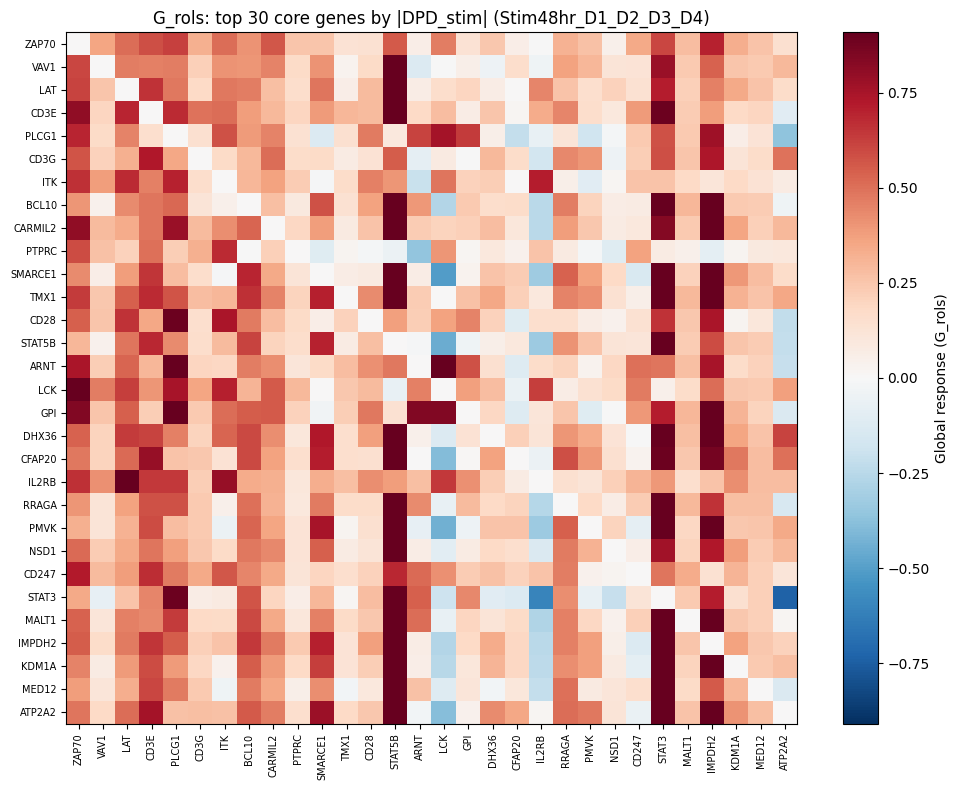

In [ ]:
top30_rols = node_df.reindex(
    node_df['DPD_stim_norm'].abs().sort_values(ascending=False).index
).head(30)['gene'].tolist()
idx30_rols = [perturbed_gene_list.index(g) for g in top30_rols if g in perturbed_gene_list]
top30_rols = [perturbed_gene_list[i] for i in idx30_rols]
G_sub = G_arr[np.ix_(idx30_rols, idx30_rols)]
vmax = np.percentile(np.abs(G_sub[~np.eye(len(G_sub), dtype=bool)]), 95)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(G_sub, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(top30_rols)))
ax.set_yticks(range(len(top30_rols)))
ax.set_xticklabels(top30_rols, rotation=90, fontsize=7)
ax.set_yticklabels(top30_rols, fontsize=7)
ax.set_title(f'G_rols: top 30 core genes by |DPD_stim| ({run_tag})')
plt.colorbar(im, ax=ax, label='Global response (G_rols)')
plt.tight_layout()
plt.savefig(os.path.join(ROLS_OUT, f'G_rols_heatmap_top30_{run_tag}.png'), dpi=150)
plt.show()

PCA on G_rols rows (197 genes x 197 targets)
PC1 explains: 51.8%
PC1+PC2 explain: 66.2%
Components needed for 80% variance: 5
Components needed for 90% variance: 18


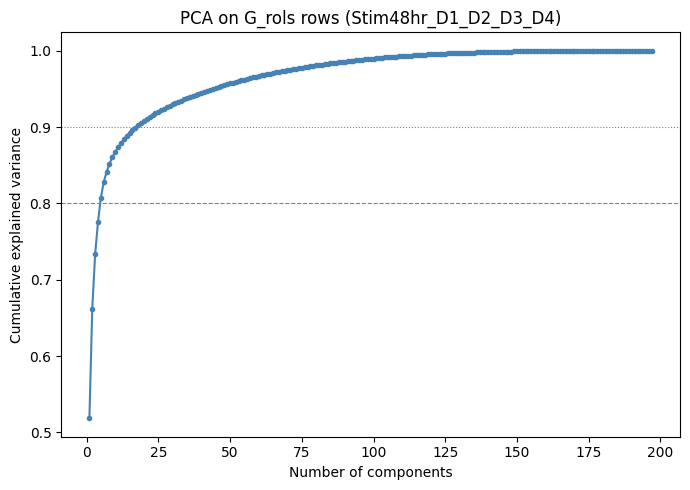

In [ ]:
pca = PCA()
pca.fit(G_arr)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

n_for_80 = int(np.searchsorted(cumulative, 0.80) + 1)
n_for_90 = int(np.searchsorted(cumulative, 0.90) + 1)

print(f'PCA on G_rols rows ({G_arr.shape[0]} genes x {G_arr.shape[1]} targets)')
print(f'PC1 explains: {explained[0]*100:.1f}%')
print(f'PC1+PC2 explain: {(explained[0]+explained[1])*100:.1f}%')
print(f'Components needed for 80% variance: {n_for_80}')
print(f'Components needed for 90% variance: {n_for_90}')

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(range(1, len(cumulative) + 1), cumulative, marker='o', markersize=3, color='steelblue')
ax.axhline(0.80, color='grey', linewidth=0.8, linestyle='--')
ax.axhline(0.90, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title(f'PCA on G_rols rows ({run_tag})')
plt.tight_layout()
plt.savefig(os.path.join(ROLS_OUT, f'G_rols_pca_variance_{run_tag}.png'), dpi=150)
plt.show()

In [ ]:
eigvals, eigvecs = np.linalg.eig(A_arr)
order = np.argsort(np.abs(eigvals))
eigvals_sorted_full = eigvals[order]
eigvecs_sorted_full = eigvecs[:, order]

print(f'Smallest |eigenvalue|: {np.abs(eigvals_sorted_full[0]):.6f}')
print(f'Second smallest |eigenvalue|: {np.abs(eigvals_sorted_full[1]):.6f}')
print(f'Ratio (2nd smallest / smallest): {np.abs(eigvals_sorted_full[1]) / np.abs(eigvals_sorted_full[0]):.2f}')

dominant_vec = np.real(eigvecs_sorted_full[:, 0])
loadings = pd.Series(dominant_vec, index=perturbed_gene_list).sort_values(key=abs, ascending=False)
print('\nTop 15 genes by |loading| on the dominant (smallest-eigenvalue) eigenvector:')
print(loadings.head(15).to_string())

Smallest |eigenvalue|: 0.022332
Second smallest |eigenvalue|: 0.069336
Ratio (2nd smallest / smallest): 3.10

Top 15 genes by |loading| on the dominant (smallest-eigenvalue) eigenvector:
PPP6C      0.105056
C1D        0.098181
ATP2A2     0.097920
TUFM       0.097881
RTRAF      0.096508
CPSF6      0.094617
TMX1       0.094095
COX6C      0.093997
AMD1       0.093878
COASY      0.093241
SUPV3L1    0.093201
UBE2V2     0.092840
CUL3       0.092291
EIF4G2     0.092232
ATF4       0.091951


Correlation |loading| vs n_sig_genes: -0.1757


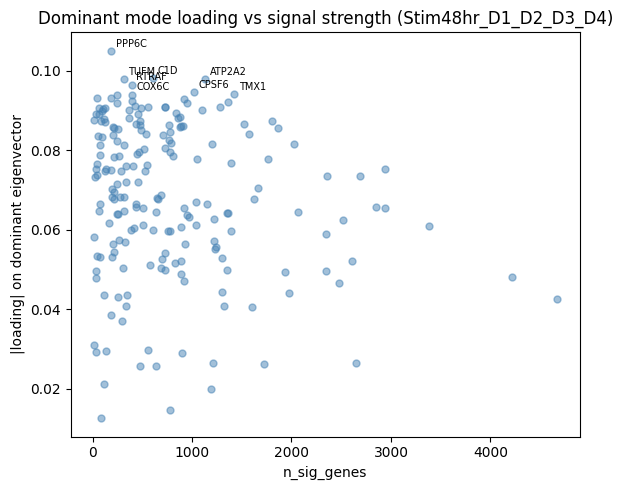

In [ ]:
loadings_full = pd.Series(dominant_vec, index=perturbed_gene_list)
n_sig_aligned = core_df.set_index('target_contrast_gene_name')['n_sig_genes'].reindex(perturbed_gene_list)

corr_loading_nsig = np.corrcoef(np.abs(loadings_full.values), n_sig_aligned.values)[0, 1]
print(f'Correlation |loading| vs n_sig_genes: {corr_loading_nsig:.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(n_sig_aligned.values, np.abs(loadings_full.values), alpha=0.5, s=25, color='steelblue')
ax.set_xlabel('n_sig_genes')
ax.set_ylabel('|loading| on dominant eigenvector')
ax.set_title(f'Dominant mode loading vs signal strength ({run_tag})')
for g in loadings_full.abs().sort_values(ascending=False).head(8).index:
    ax.annotate(g, (n_sig_aligned[g], abs(loadings_full[g])), fontsize=7, xytext=(3, 3), textcoords='offset points')
plt.tight_layout()
plt.savefig(os.path.join(ROLS_OUT, f'loading_vs_nsig_{run_tag}.png'), dpi=150)
plt.show()

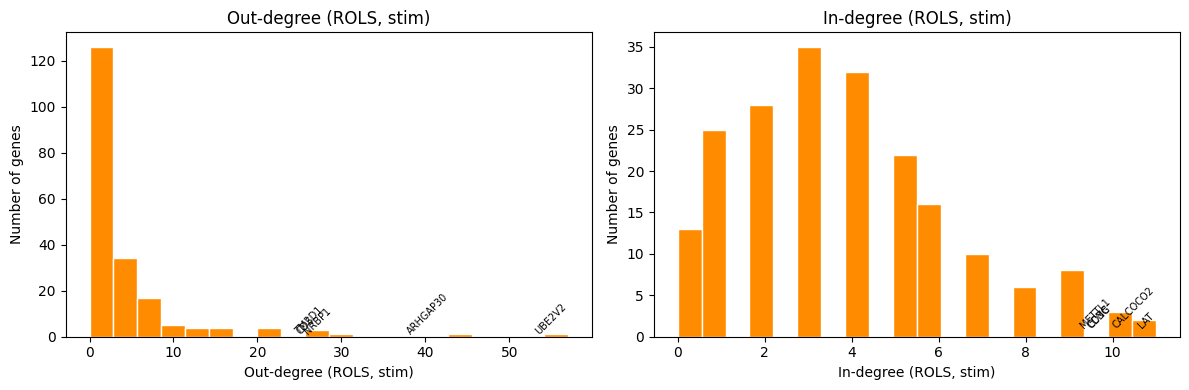

In [ ]:
if 'out_rols_stim' in node_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, col, label in [
        (axes[0], 'out_rols_stim', 'Out-degree (ROLS, stim)'),
        (axes[1], 'in_rols_stim', 'In-degree (ROLS, stim)')]:
        ax.hist(node_df[col], bins=20, edgecolor='white', color='darkorange')
        ax.set_xlabel(label)
        ax.set_ylabel('Number of genes')
        ax.set_title(label)
        for _, row in node_df.nlargest(5, col).iterrows():
            ax.annotate(row['gene'], xy=(row[col], 0),
                        xytext=(row[col], 1), fontsize=7, ha='right', rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(ROLS_OUT, f'degree_distribution_rols_{run_tag}.png'), dpi=150)
    plt.show()

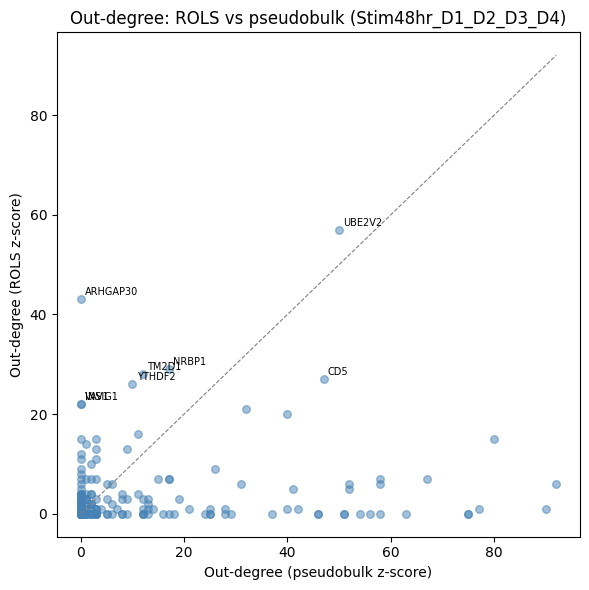

In [ ]:
# checking degree number matches
if 'out_rols_stim' in node_df.columns and 'out_pseudo_stim' in node_df.columns:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(node_df['out_pseudo_stim'], node_df['out_rols_stim'],
               alpha=0.5, s=30, color='steelblue')
    max_val = max(node_df['out_pseudo_stim'].max(), node_df['out_rols_stim'].max())
    ax.plot([0, max_val], [0, max_val], color='grey', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Out-degree (pseudobulk z-score)')
    ax.set_ylabel('Out-degree (ROLS z-score)')
    ax.set_title(f'Out-degree: ROLS vs pseudobulk ({run_tag})')
    for _, row in node_df.nlargest(8, 'out_rols_stim').iterrows():
        ax.annotate(row['gene'], (row['out_pseudo_stim'], row['out_rols_stim']),
                    fontsize=7, xytext=(3, 3), textcoords='offset points')
    plt.tight_layout()
    plt.savefig(os.path.join(ROLS_OUT, f'degree_rols_vs_pseudo_{run_tag}.png'), dpi=150)
    plt.show()

**z-score degrees**

Top 15 hub genes by total stim degree
   gene  DPD_stim_norm  n_sig_genes  out_pseudo_stim  in_pseudo_stim  total_stim
  PPP6C       0.904473          190               90              58         148
   CBLB       0.219781          110               92              25         117
SMARCB1      -1.091003          728               52              64         116
   UPF2       0.342727          333               46              70         116
 INTS10      -0.933914         1518               58              53         111
  CPSF6       0.646575         1021               42              67         109
   CBFB       0.448511          765               40              67         107
  BTAF1      -1.354696          886               63              41         104
   PTPA       0.416184          730               77              25         102
  EIF3L       0.397084          122               75              24          99
  ACYP2       0.232738          209               80              16   

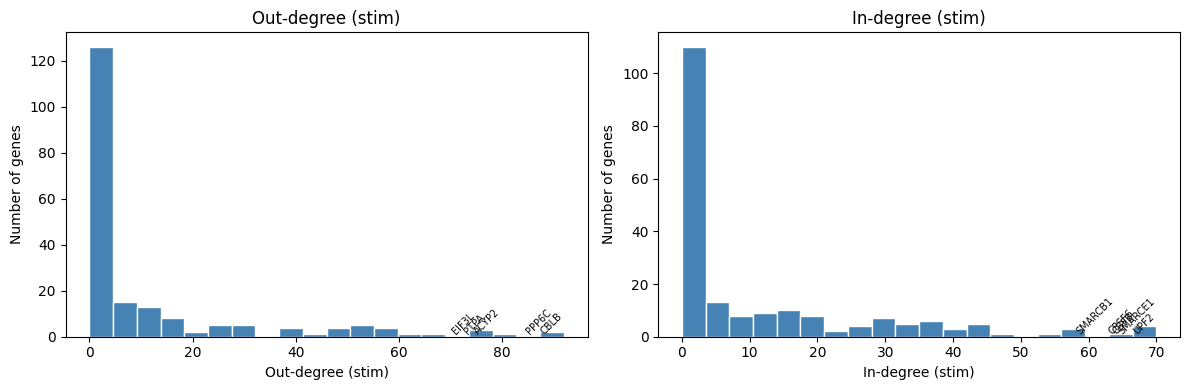

In [ ]:
deg_df = node_df[['gene', 'DPD_stim_norm', 'n_sig_genes']].copy()
for col in ['out_pseudo_stim', 'in_pseudo_stim']:
    if col in node_df.columns:
        deg_df[col] = node_df[col]

if 'out_pseudo_stim' in deg_df.columns:
    deg_df['total_stim'] = deg_df.get('out_pseudo_stim', 0) + deg_df.get('in_pseudo_stim', 0)
    print('Top 15 hub genes by total stim degree')
    print(deg_df.sort_values('total_stim', ascending=False).head(15).to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, col, label in [
        (axes[0], 'out_pseudo_stim', 'Out-degree (stim)'),
        (axes[1], 'in_pseudo_stim', 'In-degree (stim)')]:
        ax.hist(node_df[col], bins=20, edgecolor='white', color='steelblue')
        ax.set_xlabel(label)
        ax.set_ylabel('Number of genes')
        ax.set_title(label)
        for _, row in node_df.nlargest(5, col).iterrows():
            ax.annotate(row['gene'], xy=(row[col], 0),
                        xytext=(row[col], 1), fontsize=7, ha='right', rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(PSEUDO_OUT, f'degree_distribution_{run_tag}.png'), dpi=150)
    plt.show()

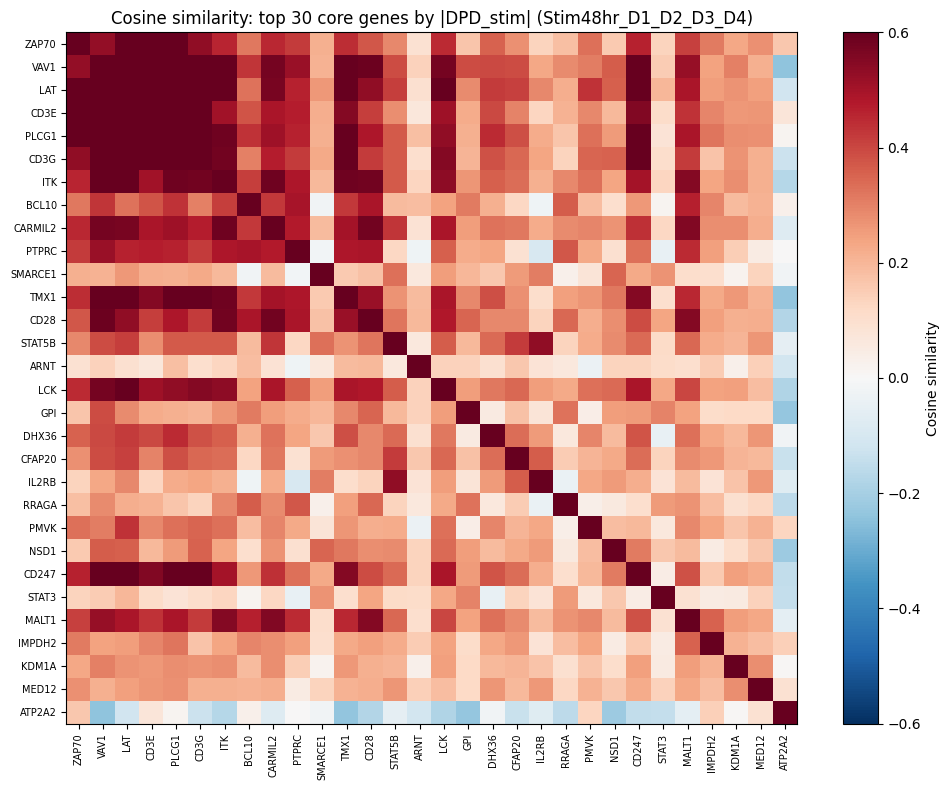

In [ ]:
top30 = node_df.reindex(
    node_df['DPD_stim_norm'].abs().sort_values(ascending=False).index
).head(30)['gene'].tolist()
idx30 = [core_genes.index(g) for g in top30]
cos_sub = cosine_stim[np.ix_(idx30, idx30)]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cos_sub, cmap='RdBu_r', vmin=-0.6, vmax=0.6, aspect='auto')
ax.set_xticks(range(len(top30)))
ax.set_yticks(range(len(top30)))
ax.set_xticklabels(top30, rotation=90, fontsize=7)
ax.set_yticklabels(top30, fontsize=7)
ax.set_title(f'Cosine similarity: top 30 core genes by |DPD_stim| ({run_tag})')
plt.colorbar(im, ax=ax, label='Cosine similarity')
plt.tight_layout()
plt.savefig(os.path.join(PSEUDO_OUT, f'cosine_heatmap_top30_{run_tag}.png'), dpi=150)
plt.show()

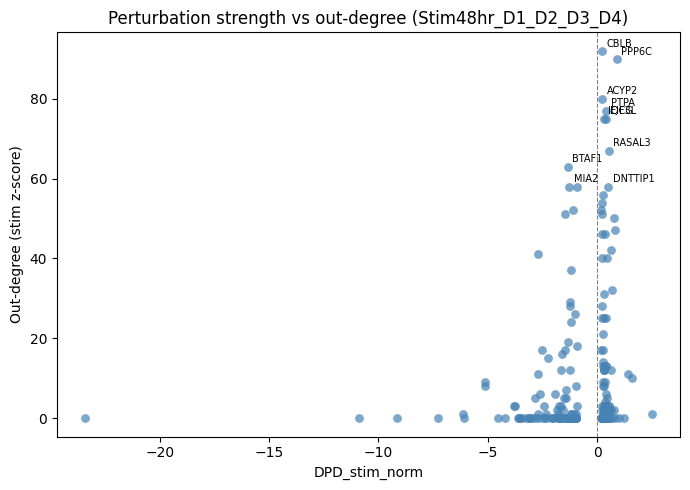

In [ ]:
if 'out_pseudo_stim' in node_df.columns:
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(
        node_df['DPD_stim_norm'],
        node_df['out_pseudo_stim'],
        c=node_df['DPD_btla_norm'] if not SKIP_BTLA else 'steelblue',
        cmap='coolwarm' if not SKIP_BTLA else None,
        alpha=0.7, s=40, linewidths=0)
    if not SKIP_BTLA:
        plt.colorbar(sc, ax=ax, label='DPD_btla_norm')
    ax.set_xlabel('DPD_stim_norm')
    ax.set_ylabel('Out-degree (stim z-score)')
    ax.set_title(f'Perturbation strength vs out-degree ({run_tag})')
    ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
    for _, row in node_df.nlargest(10, 'out_pseudo_stim').iterrows():
        ax.annotate(row['gene'], (row['DPD_stim_norm'], row['out_pseudo_stim']),
                    fontsize=7, xytext=(3, 3), textcoords='offset points')
    plt.tight_layout()
    plt.savefig(os.path.join(PSEUDO_OUT, f'dpd_vs_degree_{run_tag}.png'), dpi=150)
    plt.show()